In [31]:
import numpy as np
import pandas as pd


In [32]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

## Q1. Sales Data Analysis
You are a data analyst at an e-commerce company. Your task is to analyze sales data, clean and process it, perform statistical analysis, and generate visual insights to help the business make informed decisions. 1.Use your roll number as the random seed to generate unique data for each student



In [34]:
roll_num = 102316036
np.random.seed(roll_num)

# Part I: Randomized Sales Data Generation (NumPy)

In [35]:
np.random.seed(42)

sales_data = np.random.randint(1000, 5001, size=(12, 4))  

columns = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sales_df = pd.DataFrame(sales_data, columns=columns, index=months)


print(sales_df)

     Electronics  Clothing  Home & Kitchen  Sports
Jan         4174      4507            1860    2294
Feb         2130      2095            4772    4092
Mar         2638      3169            1466    2238
Apr         1330      2482            3135    4444
May         4171      3919            4735    1130
Jun         2685      4380            1769    3391
Jul         2515      4485            3853    3433
Aug         2215      1955            3324    2184
Sep         1459      4385            1021    3300
Oct         1747      3904            4632    1474
Nov         2082      3558            4753    3047
Dec         4547      3747            1975    2806


## Part II: Data Manipulation and Analysis (Pandas)
1. Display the first 5 rows and summary statistics of the DataFrame.
2. Calculate the total sales per category and total sales per month.
3. Calculate the average sales growth between consecuƟve months for each category.
4. Add the following columns to the DataFrame:
 Total Sales: Sum of all categories per month.
 Growth Rate: Percentage change in Total Sales from the previous month.
5. Apply a randomized discount:
 If your roll number is even, apply a 10% discount to the Electronics category.
 If odd, apply a 15% discount to the Clothing category

In [36]:
print("First 5 Rows:\n")
print(sales_df.head())

print("\nSummary Statistics:\n")
print(sales_df.describe())

First 5 Rows:

     Electronics  Clothing  Home & Kitchen  Sports
Jan         4174      4507            1860    2294
Feb         2130      2095            4772    4092
Mar         2638      3169            1466    2238
Apr         1330      2482            3135    4444
May         4171      3919            4735    1130

Summary Statistics:

       Electronics     Clothing  Home & Kitchen       Sports
count    12.000000    12.000000       12.000000    12.000000
mean   2641.083333  3548.833333     3107.916667  2819.416667
std    1087.608089   925.564578     1437.576335   996.676428
min    1330.000000  1955.000000     1021.000000  1130.000000
25%    1998.250000  2997.250000     1837.250000  2224.500000
50%    2365.000000  3825.500000     3229.500000  2926.500000
75%    3056.500000  4381.250000     4657.750000  3401.500000
max    4547.000000  4507.000000     4772.000000  4444.000000


In [37]:
total_sales_per_category = sales_df.sum()
total_sales_per_month = sales_df.sum(axis=1)

print("\nTotal Sales Per Category:\n")
print(total_sales_per_category)

print("\nTotal Sales Per Month:\n")
print(total_sales_per_month)


Total Sales Per Category:

Electronics       31693
Clothing          42586
Home & Kitchen    37295
Sports            33833
dtype: int64

Total Sales Per Month:

Jan    12835
Feb    13089
Mar     9511
Apr    11391
May    13955
Jun    12225
Jul    14286
Aug     9678
Sep    10165
Oct    11757
Nov    13440
Dec    13075
dtype: int64


In [38]:
average_growth = sales_df.pct_change().mean() * 100

print("\nAverage Monthly Sales Growth (%):\n")
print(average_growth)


Average Monthly Sales Growth (%):

Electronics       18.927203
Clothing           9.226654
Home & Kitchen    47.468630
Sports            28.780511
dtype: float64


In [39]:
sales_df['Total Sales'] = total_sales_per_month
sales_df['Growth Rate (%)'] = sales_df['Total Sales'].pct_change() * 100

print("\nDataFrame with Total Sales and Growth Rate:\n")
print(sales_df)


DataFrame with Total Sales and Growth Rate:

     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  \
Jan         4174      4507            1860    2294        12835   
Feb         2130      2095            4772    4092        13089   
Mar         2638      3169            1466    2238         9511   
Apr         1330      2482            3135    4444        11391   
May         4171      3919            4735    1130        13955   
Jun         2685      4380            1769    3391        12225   
Jul         2515      4485            3853    3433        14286   
Aug         2215      1955            3324    2184         9678   
Sep         1459      4385            1021    3300        10165   
Oct         1747      3904            4632    1474        11757   
Nov         2082      3558            4753    3047        13440   
Dec         4547      3747            1975    2806        13075   

     Growth Rate (%)  
Jan              NaN  
Feb         1.978964  
Mar       -27

In [40]:
if roll_num% 2 == 0:
    sales_df['Electronics'] = sales_df['Electronics'] * 0.9
else:
    sales_df['Clothing'] = sales_df['Clothing'] * 0.85

print("\nFinal DataFrame after Discount:\n")
print(sales_df)


Final DataFrame after Discount:

     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  \
Jan       3756.6      4507            1860    2294        12835   
Feb       1917.0      2095            4772    4092        13089   
Mar       2374.2      3169            1466    2238         9511   
Apr       1197.0      2482            3135    4444        11391   
May       3753.9      3919            4735    1130        13955   
Jun       2416.5      4380            1769    3391        12225   
Jul       2263.5      4485            3853    3433        14286   
Aug       1993.5      1955            3324    2184         9678   
Sep       1313.1      4385            1021    3300        10165   
Oct       1572.3      3904            4632    1474        11757   
Nov       1873.8      3558            4753    3047        13440   
Dec       4092.3      3747            1975    2806        13075   

     Growth Rate (%)  
Jan              NaN  
Feb         1.978964  
Mar       -27.335931  
Ap

### 1. Plot monthly sales trends for each category using line plots.
### 2. Create the following plots:
        Box plots to show the sales distribuƟon for each category

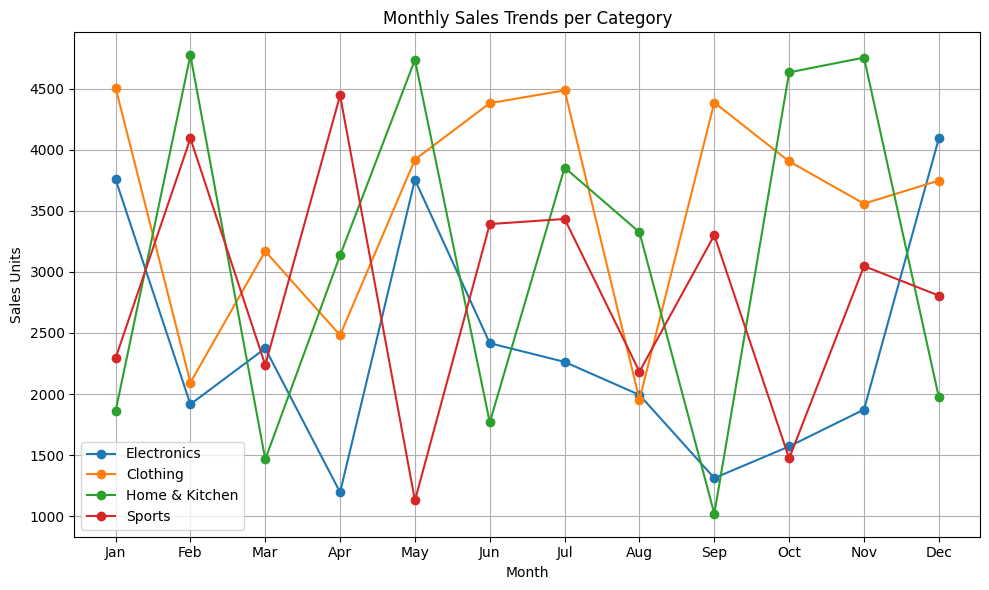

In [41]:
plt.figure(figsize=(10, 6))
for column in ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']:
    plt.plot(sales_df.index, sales_df[column], marker='o', label=column)

plt.title("Monthly Sales Trends per Category")
plt.xlabel("Month")
plt.ylabel("Sales Units")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

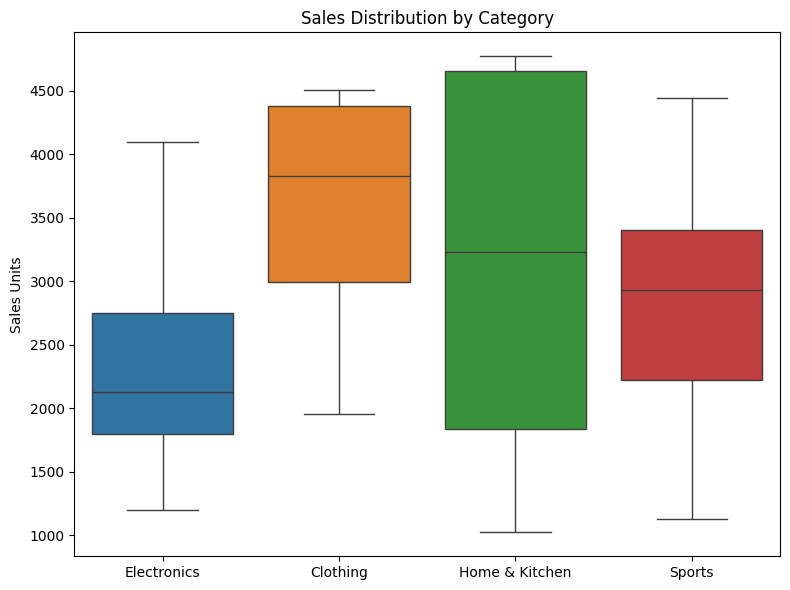

In [42]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=sales_df[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']])
plt.title("Sales Distribution by Category")
plt.ylabel("Sales Units")
plt.tight_layout()
plt.show()

### Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])
 i. Find element-wise absolute value
ii. Find the 25th, 50th, and 75th percenƟle of flaƩened array, for each column, for each
row.
iii. Mean, Median and Standard DeviaƟon of flaƩened array, of each column, and
each row 


In [44]:

array = np.array([[1, -2, 3],
                  [-4, 5, -6]])
abs_array = np.abs(array)
abs_array

array([[1, 2, 3],
       [4, 5, 6]])

ii. 25th, 50th, and 75th percentiles

In [45]:
flat = array.flatten()
np.percentile(flat, [25, 50, 75])


array([-3.5, -0.5,  2.5])

In [46]:
np.percentile(array, [25, 50, 75], axis=0)


array([[-2.75, -0.25, -3.75],
       [-1.5 ,  1.5 , -1.5 ],
       [-0.25,  3.25,  0.75]])

In [47]:
np.percentile(array, [25, 50, 75], axis=1)

array([[-0.5, -5. ],
       [ 1. , -4. ],
       [ 2. ,  0.5]])

iii. Mean, Median, and Standard Deviation

In [51]:
mean_flat = np.mean(flat)
median_flat = np.median(flat)
std_flat = np.std(flat)
mean_col = np.mean(array, axis=0)
median_col = np.median(array, axis=0)
std_col = np.std(array, axis=0)
mean_row = np.mean(array, axis=1)
median_row = np.median(array, axis=1)
std_row = np.std(array, axis=1)
print(mean_flat)
print(median_flat)
print(std_flat)
print(mean_col)
print(median_col)
print(std_col)
print(mean_row)
print(median_row)
print(std_row)

-0.5
-0.5
3.8622100754188224
[-1.5  1.5 -1.5]
[-1.5  1.5 -1.5]
[2.5 3.5 4.5]
[ 0.66666667 -1.66666667]
[ 1. -4.]
[2.05480467 4.78423336]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).
 i. Find floor, ceiling and truncated value, rounded values

In [52]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

floor_values = np.floor(a)
ceil_values = np.ceil(a)
trunc_values = np.trunc(a)

print("Original array:", a)
print("Floor values:  ", floor_values)
print("Ceil values:   ", ceil_values)
print("Trunc values:  ", trunc_values)

Original array: [-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]
Floor values:   [-2. -2. -1.  0.  1.  1.  3.]
Ceil values:    [-1. -1. -0.  1.  2.  2.  3.]
Trunc values:   [-1. -1. -0.  0.  1.  1.  3.]


In [53]:
my_list = [10, 20, 30, 40, 50]

# Indexes to swap
i = 1
j = 3

# Swapping using a temporary variable
temp = my_list[i]
my_list[i] = my_list[j]
my_list[j] = temp

print("List after swapping:", my_list)


List after swapping: [10, 40, 30, 20, 50]


In [54]:
my_set = {10, 20, 30, 40, 50}

# Convert set to list
temp_list = list(my_set)

# Indexes to swap (e.g., index 0 and 2)
i = 0
j = 2

# Swap using a temporary variable
temp = temp_list[i]
temp_list[i] = temp_list[j]
temp_list[j] = temp

# Convert list back to set
swapped_set = set(temp_list)

print("Set after swapping (converted back from list):", swapped_set)

Set after swapping (converted back from list): {40, 10, 50, 20, 30}
